### LOGISTIC REGRESSION

#### 1. Data Exploration:
a. Load the dataset and perform exploratory data analysis (EDA).

b. Examine the features, their types, and summary statistics.

c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

d.Analyze any patterns or correlations observed in the data.


In [1]:
#Load the Dataset
import pandas as pd
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
#shape of the Dataset
df.shape

(768, 9)

In [3]:
#Check the Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [47]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
#Checking Missing Values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### Check Target Distribution

In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#### VISUALISATION

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

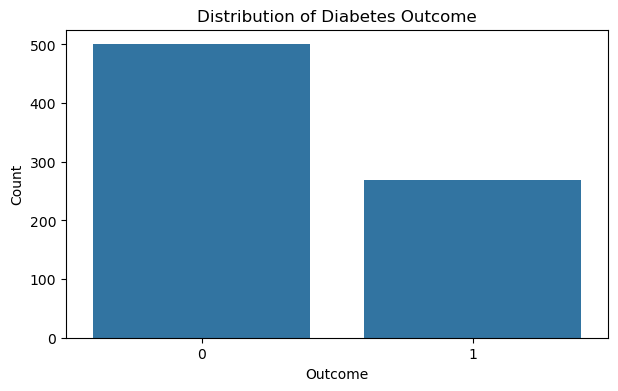

In [9]:
plt.figure(figsize=(7,4))
sns.countplot(data=df,x='Outcome')
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

### HISTOGRAMS

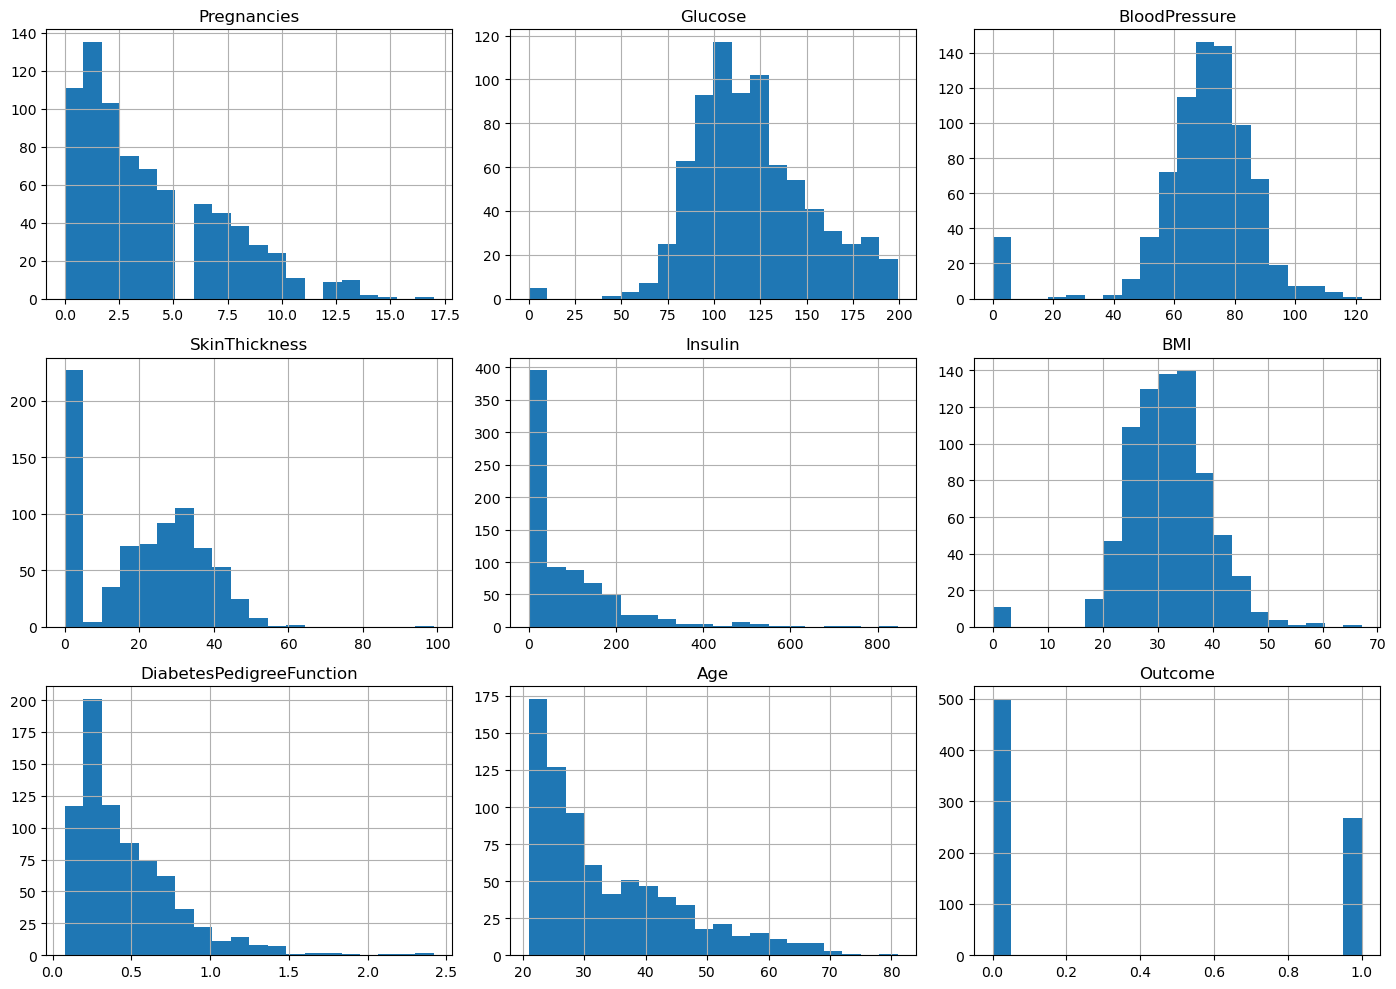

In [13]:
df.hist(figsize=(14,10),
        bins=20,
)
plt.tight_layout()
plt.show()

#### Findings

The variables have different distributions.

#### For example:

- Glucose has a broad distribution.
- Age is concentrated more heavily among younger observations.
- Insulin is strongly right-skewed.
- DiabetesPedigreeFunction is also right-skewed.

### BOXPLOT

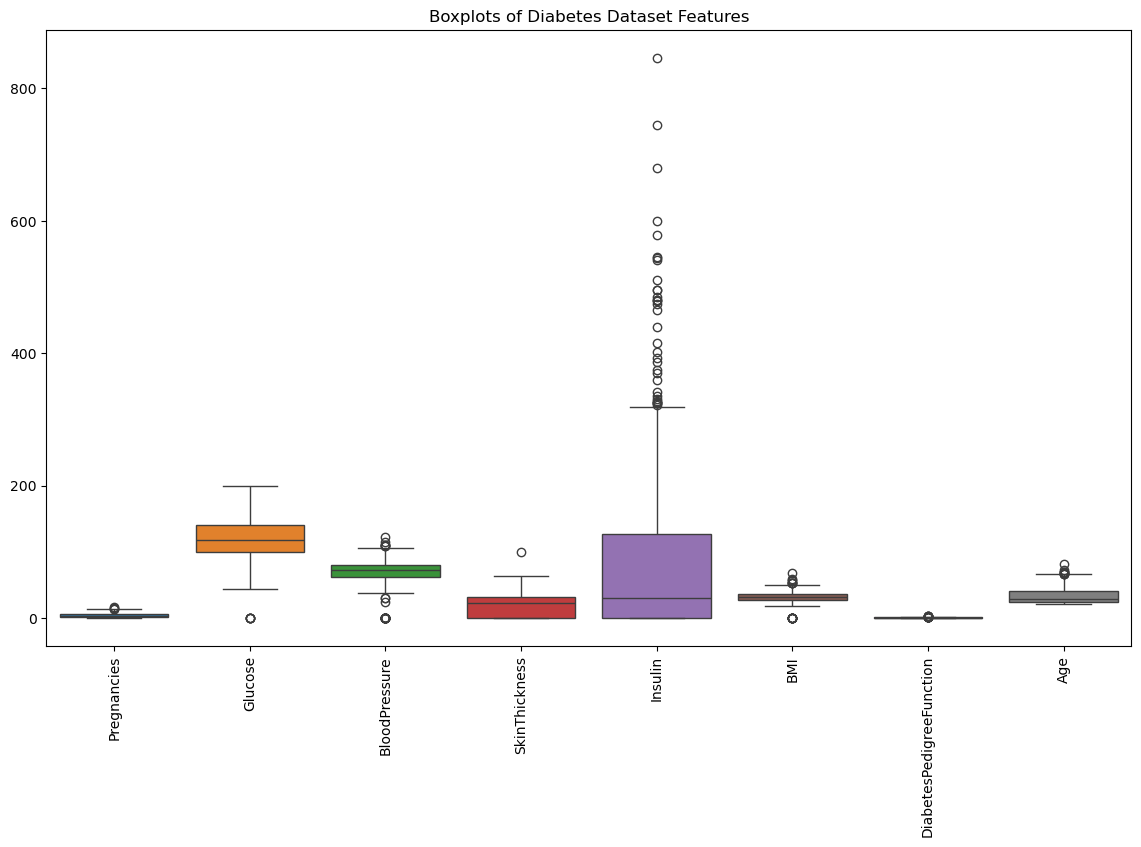

In [15]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df.drop(columns='Outcome'))
plt.xticks(rotation=90)
plt.title("Boxplots of Diabetes Dataset Features")
plt.show()

#### Finding

Some variables contain potential extreme observations, especially:

- Insulin
- DiabetesPedigreeFunction
- SkinThickness
- BMI

We should not automatically delete these observations because they may represent genuine measurements.

### Correlation Heatmap
#### Explanation

- A correlation matrix helps us understand the linear relationship between the numerical variables and Outcome.

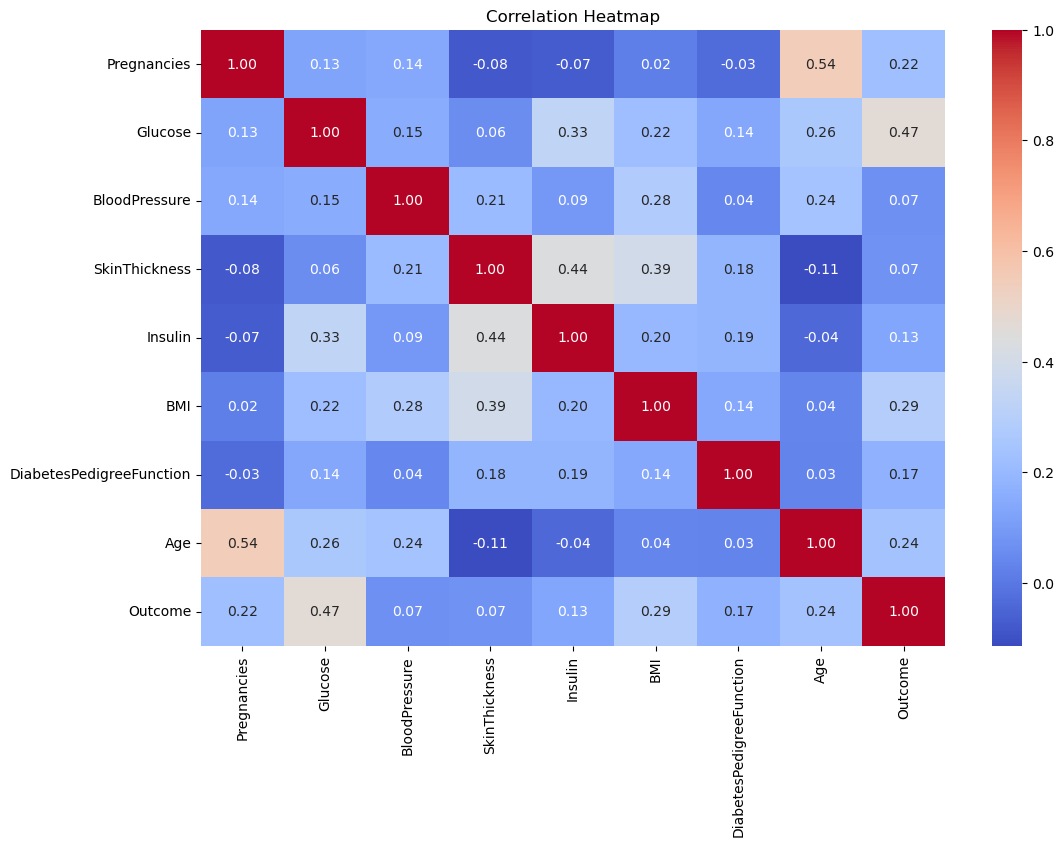

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
df.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

### Finding

- Glucose has the strongest positive correlation with Outcome among the available variables.

- However, correlation alone does not determine whether a variable should be included or whether it causes the outcome

### 2. Data Preprocessing:
#### a. Handle missing values (e.g., imputation).
#### b. Encode categorical variables.

- There are no categorical predictor variables in this dataset, so categorical encoding is not required.

### Model Building:
a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).

b. Train the model using the training data.


### Separate X and y

In [20]:
X=df.drop(columns=['Outcome'])
y=df['Outcome']

#### Split the Dataset

##### Explanation

We divide the dataset into training and testing data.

We use:

80% -->Training
20% -->Testing

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


#### Create Logistic Regression Model

In [23]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [25]:
#fit the model
model.fit(X_train,y_train)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
#Predict the Model
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

### 4. Model Evaluation:
##### a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
##### b.Visualize the ROC curve.


In [28]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

### Accuracy
#### Explanation

Accuracy represents the proportion of all predictions that were correct.

Formula:

$$ Accuracy = \frac{Correct\ Predictions}{Total\ Predictions} $$


In [30]:
accuracy = accuracy_score(y_test, y_pred_test)
print("Accuracy:", accuracy)

Accuracy: 0.7467532467532467


### Precision
#### Explanation

Precision tells us:

Of all observations predicted as diabetic, how many were actually diabetic?

In [32]:
precision = precision_score(y_test, y_pred_test)
print("Precision:", precision)

Precision: 0.6379310344827587


- So approximately 60% of the positive predictions were actually positive.

### Recall
#### Explanation



Of all actually diabetic observations, how many did the model correctly identify.

In [34]:
recall = recall_score(y_test, y_pred_test)
print("Recall:", recall)

Recall: 0.6727272727272727


- The model correctly identified approximately 50% of the actual positive cases.

### F1-Score
- F1-score combines precision and recall into one metric

In [35]:
f1 = f1_score(y_test, y_pred_test)
print("F1-Score:", f1)

F1-Score: 0.6548672566371682


### ROC-AUC Score
#### Explanation

ROC-AUC evaluates how well the model separates the two classes across different classification thresholds.


### Predict Probabilities
#### Explanation

Logistic regression can also provide the probability of belonging to each class.

In [38]:
y_probability =model.predict_proba(X_test)[:, 1]

In [39]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8126721763085399


In [40]:
# Display All Evaluation Metrics

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7467532467532467
Precision: 0.6379310344827587
Recall   : 0.6727272727272727
F1-Score : 0.6548672566371682
ROC-AUC  : 0.8126721763085399


### ROC Curve
#### Explanation

The ROC curve shows the relationship between:

- True Positive Rate
- False Positive Rate

at different classification thresholds.

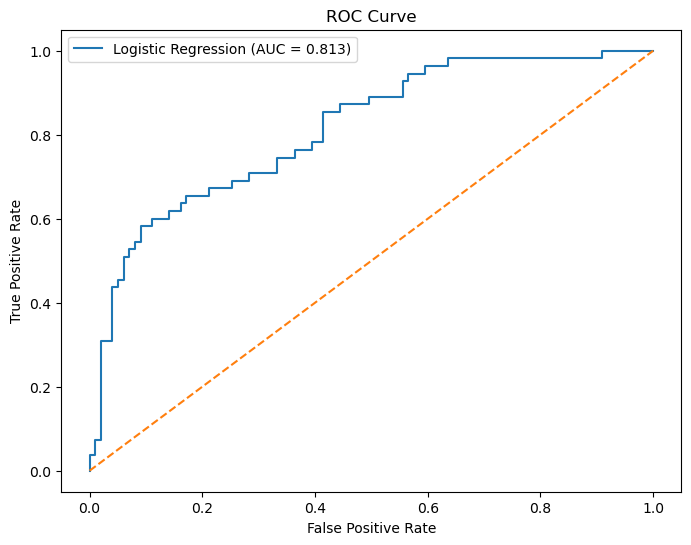

In [41]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

### 5. Interpretation:
- a. Interpret the coefficients of the logistic regression model.
- b. Discuss the significance of features in predicting the target variable (survival probability in this case).


In [44]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient':model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.608198
5,BMI,0.101845
0,Pregnancies,0.064500
7,Age,0.036336
1,Glucose,0.033825
3,SkinThickness,0.003904
4,Insulin,-0.001851
2,BloodPressure,-0.013361


### 6. Deployment with Streamlit:

In [45]:
#convering it into .pkl format
import joblib 
joblib.dump(model,'Diabetes_logistic_model.pkl')

['Diabetes_logistic_model.pkl']

In [48]:
import streamlit as st
import joblib
import numpy as np

# Load trained model
model = joblib.load("diabetes_logistic_model.pkl")

st.title("Diabetes Prediction App")

st.write("Enter the patient information to predict the diabetes outcome.")

Pregnancies = st.number_input("Pregnancies",min_value=0,max_value=20,value=1)
Glucose = st.number_input("Glucose",min_value=0.0,value=120.0)
BloodPressure = st.number_input("Blood Pressure",min_value=0.0,value=70.0)
SkinThickness = st.number_input("Skin Thickness",min_value=0.0,value=20.0)
Insulin = st.number_input("Insulin",min_value=0.0,value=80.0)
BMI = st.number_input("BMI",min_value=0.0,value=30.0)
DiabetesPedigreeFunction = st.number_input("Diabetes Pedigree Function",min_value=0.0,value=0.5)
Age = st.number_input("Age",min_value=1,max_value=120,value=30)

if st.button("Predict"):

    input_data = {
        "Pregnancies": Pregnancies,
        "Glucose": Glucose,
        "BloodPressure": BloodPressure,
        "SkinThickness": SkinThickness,
        "Insulin": Insulin,
        "BMI": BMI,
        "DiabetesPedigreeFunction": DiabetesPedigreeFunction,
        "Age": Age
    }

    data = pd.DataFrame([input_data])

    prediction = model.predict(data)[0]

    if prediction == 1:
        st.error("Diabetes Predicted")
    else:
        st.success("No Diabetes Predicted")


2026-09-28 18:08:18.301 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 18:08:18.649 
  command:

    streamlit run D:\Anaconda\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-28 18:08:18.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 18:08:18.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 18:08:18.651 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 18:08:18.651 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 18:08:18.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-28 18:08:18.653 Thread 'MainThread': missing ScriptR